# 09 - Modeling Geometries

Source orientation: the PDF/page audit in this notebook records the printed and PDF page span used for chapter grounding; all prose, examples, visuals, and checks here are original course material.

Chapter 9 is a bridge, so this notebook is built as a bridge rather than as a dense theorem list. Part I gave us blades, products, duals, meets, joins, rotors, and differential ideas. Those tools are powerful, but they do not automatically say what a point away from the origin is, what it means to translate a line, or which inner product should measure a Euclidean distance. A geometric algebra becomes a computational geometry only after we choose a model: a representational space, a metric, an embedding, and an interpretation rule for operations.

That choice is the main subject here. The notebook uses small executable examples to make model choice visible. We will compare the vector-space model, the homogeneous model, the conformal model, and the broader operational viewpoint that closes Part II. The examples are deliberately simple: offset lines in a plane, conformal point embeddings, distance checks, and transformation checks. The point is not to solve a large graphics problem yet. The point is to learn how to ask whether a model carries the information a problem needs.

A model is not merely a container for coordinates. It is a contract. It says which Euclidean objects are represented by which algebraic elements, which products have geometric meaning, which transformations preserve the represented objects, and where the numerical warnings will appear. If the contract is weak around metric information, metric algorithms should be treated with suspicion. If the contract makes transformations into versor sandwiches, then invariants such as grade, incidence, and distance become easier to protect.

## PDF Page Audit

I checked the local PDF before writing this notebook. In this copy, printed p. 245 starts on PDF page 272, so printed pp. 245-246 correspond to PDF pages 272-273. The visible chapter heading on printed p. 245 is `9 MODELING GEOMETRIES`. No numbered section heading appears in the requested span; the two pages introduce the modeling problem and preview how Chapters 10-17 develop the vector-space, homogeneous, conformal, and operational viewpoints.

That span is short but important. It explains why the rest of Part II is not a grab bag of unrelated coordinate tricks. The common pattern is to take the algebraic products from Part I and ask where they should live so that familiar geometric objects become native objects of computation. Sometimes the right answer is the original vector space. Sometimes one extra coordinate makes incidence linear. Sometimes two extra null directions are worth the cost because they make Euclidean distance and motion part of the algebra instead of an external patch.

This notebook follows that conceptual route with original exposition and fresh executable checks. The page audit is saved as an artifact so later validation can tell exactly which printed span was used as the anchor.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

BOOK_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils" / "artifacts.py").exists():
        BOOK_ROOT = candidate
        break

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib
from utils.chapter09_modeling_geometries import (
    chapter_route,
    conformal_distance_squared_2d,
    conformal_inner_2d,
    conformal_point_2d,
    euclidean_distance_matrix,
    homogeneous_line_from_points,
    homogeneous_point_2d,
    intersect_homogeneous_lines,
    line_residual,
    normalize_homogeneous,
    null_residual,
    profile_table,
    rotate2d,
    score_matrix,
    transform_line,
    translation_matrix,
)

np.set_printoptions(precision=5, suppress=True)
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
ARTIFACT_TOPIC = "chapter-09"
BOOK_ROOT


WindowsPath('Geometric-Algebra-for-Computer-Science')

In [2]:
heading_audit = [
    {
        "printed_page": 245,
        "pdf_page": 272,
        "heading": "9 MODELING GEOMETRIES",
        "role": "chapter opener and model-choice motivation",
    },
    {
        "printed_page": 246,
        "pdf_page": 273,
        "heading": "continuation of Chapter 9 opener",
        "role": "preview of vector-space, homogeneous, conformal, and operational models",
    },
]

heading_path = save_json(heading_audit, ARTIFACT_TOPIC, "pdf", "heading-audit.json", root=ARTIFACT_ROOT)
print(f"saved {heading_path}")
heading_audit


saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/pdf/heading-audit.json


[{'printed_page': 245,
  'pdf_page': 272,
  'heading': '9 MODELING GEOMETRIES',
  'role': 'chapter opener and model-choice motivation'},
 {'printed_page': 246,
  'pdf_page': 273,
  'heading': 'continuation of Chapter 9 opener',
  'role': 'preview of vector-space, homogeneous, conformal, and operational models'}]

## A Model Is A Choice Of Native Objects

The first question for any model is not "What coordinates do I store?" but "Which objects become natural?" In the vector-space model, a vector is naturally a direction through the origin. A bivector is naturally an oriented plane attitude through the origin. Those are excellent objects if the task is angular: rotations, projections, perpendicularity, and attitude relationships are all close to the algebra's core products.

The same model is awkward for a finite point at a location. A Euclidean point can be named by a vector from an origin, but that is a modeling convention, not an origin-free object. Translate the point and the vector changes by addition. Rotate the whole coordinate frame and the same vector should transform differently. A line floating in the plane is even more revealing. Its direction is a vector-space object, but its offset from the origin is not a subspace through the origin. Forcing offset geometry into the original vector space would make ordinary geometric operations depend on side conventions.

The homogeneous model changes the native objects by adding one coordinate. Finite points become projective representatives, lines become blades or dual coefficient vectors, and parallel lines meet at points at infinity. This makes incidence beautifully uniform: join two points to get a line, meet two lines to get a point, and apply projective transformations with matrices and outermorphisms. The cost is that metric information is not as natural. A projective point knows how to lie on a line; it does not by itself know the Euclidean length of a segment in a way that behaves like a full geometric product.

The conformal model changes the native objects again. With two added null directions, Euclidean points are embedded as null vectors. Their inner product recovers squared distance, and Euclidean motions can be represented by versors. This is a larger algebra, but the payoff is that operations such as translation, rotation, reflection, inversion, and scaling fit the same sandwich pattern. That is why the conformal chapters can treat flats and rounds as first-class objects instead of as special cases.


In [3]:
profiles = profile_table()
profile_path = save_json(profiles, ARTIFACT_TOPIC, "checks", "model-profiles.json", root=ARTIFACT_ROOT)

rows = ["| Chapter | Model | Space | Embedding | Practical question |", "|---|---|---|---|---|"]
for item in profiles:
    rows.append(
        f"| {item['chapter']} | {item['model']} | {item['representational_space']} | "
        f"{item['embedding']} | {item['practical_question']} |"
    )

display(Markdown("\n".join(rows)))
print(f"saved {profile_path}")


| Chapter | Model | Space | Embedding | Practical question |
|---|---|---|---|---|
| 10 | Vector-space model | R^n | A direction, plane attitude, or volume attitude is stored as a blade. | What can be solved when only attitude and angle matter? |
| 11-12 | Homogeneous model | R^(n+1) | A Euclidean point x becomes the projective point [x, 1]. | How do finite and infinite flats meet under projective operations? |
| 13-16 | Conformal model | R^(n+1,1) | A point x becomes a null vector x + e0 + 0.5 |x|^2 einf. | How can points, flats, rounds, and Euclidean motions share one algebra? |
| 17 | Operational model choice | Chosen per geometry | Objects are accepted when their operations preserve the intended invariants. | Which representation makes the desired operations native? |

saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/checks/model-profiles.json


## Representational Space

Representational space is where the algebraic object lives. Physical space and representational space are not always the same. This distinction is easy to miss because early examples often use the same symbols for both. In a 3-D vector-space model, the physical direction and the vector that represents it both have three coordinates. In the homogeneous model, a 2-D physical point uses three coordinates. In the conformal model, the same 2-D point uses four coordinates, and a 3-D point uses five.

The extra coordinates are not decorative. They are purchased freedoms. The homogeneous extra coordinate lets a finite point and a point at infinity live in the same linear space. That is why parallel lines can have a meet instead of being treated as an exceptional branch. The conformal pair of extra coordinates goes further. One null direction acts like an origin marker and the other carries the quadratic weight that makes the point embedding null. Together they make Euclidean distance visible to the inner product.

Choosing a representational space is therefore a trade. A smaller space keeps computation and notation light. A larger space can remove special cases by making more objects linear, blade-like, or versor-operable. The right choice depends on the operations that dominate the problem. A camera-incidence problem may value homogeneous simplicity more than a native Euclidean metric. A rigid-body interpolation problem may justify conformal overhead because it wants transformations to compose and interpolate as algebraic operators.


saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/figures/model-choice-scorecard.png


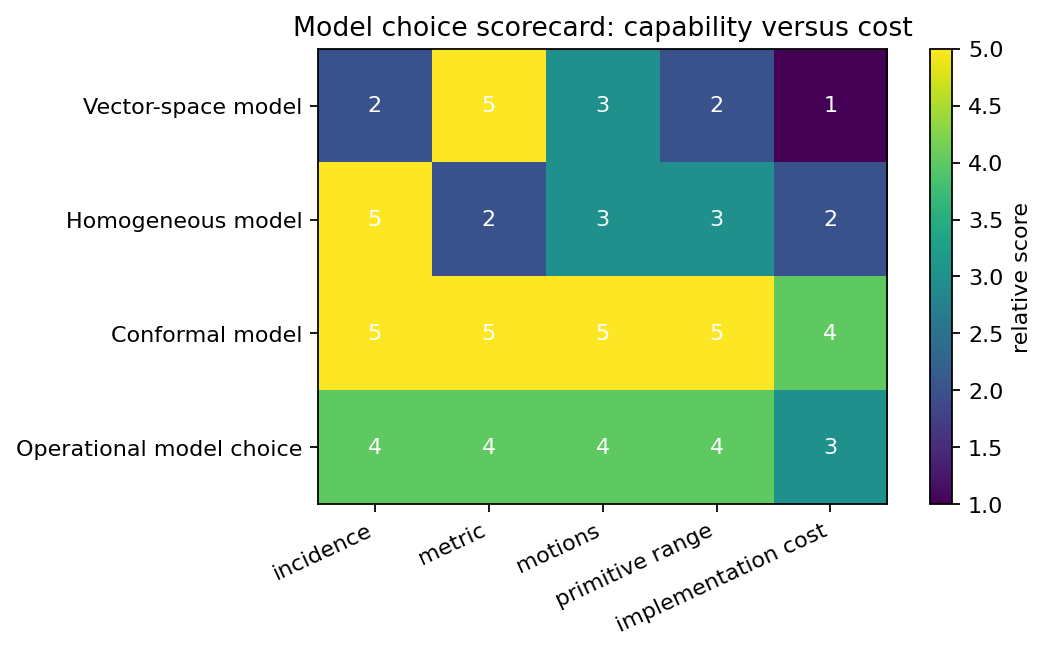

In [4]:
model_labels, criteria, scores = score_matrix()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
im = ax.imshow(scores, cmap="viridis", vmin=1, vmax=5)
ax.set_xticks(range(len(criteria)), labels=[c.replace("_", " ") for c in criteria], rotation=25, ha="right")
ax.set_yticks(range(len(model_labels)), labels=model_labels)
ax.set_title("Model choice scorecard: capability versus cost")

for row in range(scores.shape[0]):
    for col in range(scores.shape[1]):
        ax.text(col, row, f"{scores[row, col]:.0f}", ha="center", va="center", color="white", fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label("relative score")
fig.tight_layout()
scorecard_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "model-choice-scorecard.png", root=ARTIFACT_ROOT)
plt.close(fig)
print(f"saved {scorecard_path}")
display_artifact(scorecard_path, width=850)


## Metric As An Operating Budget

A metric is not only a way to compute a length. It determines which products can carry quantitative geometric meaning. In an ordinary Euclidean vector-space model, the metric lets a vector square to its squared length and lets a rotor preserve norms. That is enough for directions, angles, oriented areas, and orthogonal transformations. It is not enough for offset Euclidean incidence, because the offset is not a homogeneous subspace of the original vector space.

The homogeneous model makes the offset problem linear, but it does not automatically provide a metric that behaves like Euclidean measurement for all represented objects. This is why it is so good at projective incidence and so delicate around distances and angles. It can still support useful ratios and camera geometry, but the metric has to be handled with clear awareness of what the representation preserves.

The conformal model spends two dimensions to repair that weakness. Embedded points are null, yet the inner product between two embedded points gives Euclidean squared distance up to a fixed sign and factor. This is one of the best examples of why a model matters. The same algebraic operation, the inner product, has a different interpretive contract because the embedding and metric have been designed together.

A practical way to decide whether a model is appropriate is to list the invariants the algorithm must preserve. If the invariants are mostly incidence relationships, homogeneous tools may be enough. If the invariants include distances, angles, contact, tangency, and smooth motion composition, conformal tools become attractive. If the invariants are only directional, the plain vector-space model is often the clearest and cheapest choice.


saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/figures/homogeneous-offset-lines.png
saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/checks/homogeneous-line-meet.json


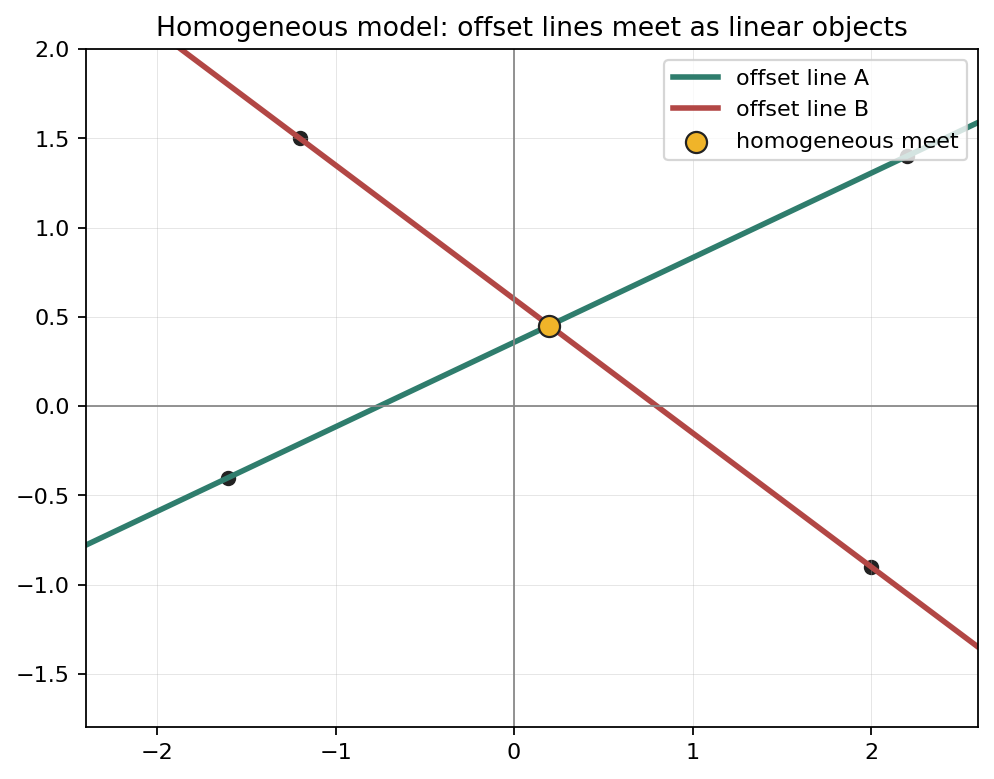

In [5]:
pa = homogeneous_point_2d(-1.6, -0.4)
pb = homogeneous_point_2d(2.2, 1.4)
pc = homogeneous_point_2d(-1.2, 1.5)
pd = homogeneous_point_2d(2.0, -0.9)

line_a = homogeneous_line_from_points(pa, pb)
line_b = homogeneous_line_from_points(pc, pd)
meet = intersect_homogeneous_lines(line_a, line_b)
meet_affine = normalize_homogeneous(meet)

homogeneous_report = {
    "line_a": line_a.tolist(),
    "line_b": line_b.tolist(),
    "meet_homogeneous": meet.tolist(),
    "meet_affine": meet_affine.tolist(),
    "residual_line_a": line_residual(line_a, meet),
    "residual_line_b": line_residual(line_b, meet),
}
assert abs(homogeneous_report["residual_line_a"]) < 1e-10
assert abs(homogeneous_report["residual_line_b"]) < 1e-10

xs = np.linspace(-2.4, 2.6, 120)
def y_on_line(line, x):
    a, b, c = line
    return -(a * x + c) / b

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.plot(xs, y_on_line(line_a, xs), color="#2f7d6d", linewidth=2.5, label="offset line A")
ax.plot(xs, y_on_line(line_b, xs), color="#b24745", linewidth=2.5, label="offset line B")
ax.scatter([pa[0], pb[0], pc[0], pd[0]], [pa[1], pb[1], pc[1], pd[1]], color="#222222", s=35)
ax.scatter([meet_affine[0]], [meet_affine[1]], color="#f0b429", edgecolor="#222222", s=90, zorder=5, label="homogeneous meet")
ax.axhline(0, color="#888888", linewidth=0.8)
ax.axvline(0, color="#888888", linewidth=0.8)
ax.set_xlim(-2.4, 2.6)
ax.set_ylim(-1.8, 2.0)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Homogeneous model: offset lines meet as linear objects")
ax.legend(loc="upper right")
ax.grid(True, linewidth=0.4, alpha=0.35)
fig.tight_layout()
line_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "homogeneous-offset-lines.png", root=ARTIFACT_ROOT)
plt.close(fig)
report_path = save_json(homogeneous_report, ARTIFACT_TOPIC, "checks", "homogeneous-line-meet.json", root=ARTIFACT_ROOT)
print(f"saved {line_path}")
print(f"saved {report_path}")
display_artifact(line_path, width=720)


## Embedding Is Interpretation, Not Storage

An embedding is the rule that turns a physical object into a representational object. It is tempting to treat embedding as a preprocessing step and then forget it. That is dangerous. The embedding is what makes later products meaningful.

In the homogeneous model, the finite point `(x, y)` becomes `[x, y, 1]`. Scaling that vector does not change the represented point, so the representation is projective. A line can be stored as coefficients `[a, b, c]`, and incidence is the zero of `a x + b y + c w`. The meet of two lines is their cross product. This is a compact computational story, but it comes with a chart: when `w` is near zero, normalizing back to affine coordinates is unstable or impossible. That is not a failure of projective geometry. It is a sign that the affine chart is the wrong view of the object.

In the conformal model, the finite point `(x, y)` becomes `[x, y, 1, 0.5 (x^2 + y^2)]` in the coordinate convention used here. The self-inner product is zero, so embedded points sit on a null surface. Two such points have an inner product that recovers Euclidean distance. This embedding looks stranger than homogeneous coordinates, but the strangeness is doing work. It stores enough quadratic information that a linear inner product can read a nonlinear Euclidean quantity.

A good implementation keeps embedding and de-embedding functions explicit. That makes it harder to accidentally compare raw coordinates from different models, and it gives validation code a place to check invariants: homogeneous residuals for incidence, conformal null residuals for point validity, and distance identities for metric correctness.


saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/figures/conformal-point-embedding.png
saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/checks/conformal-distance-check.json


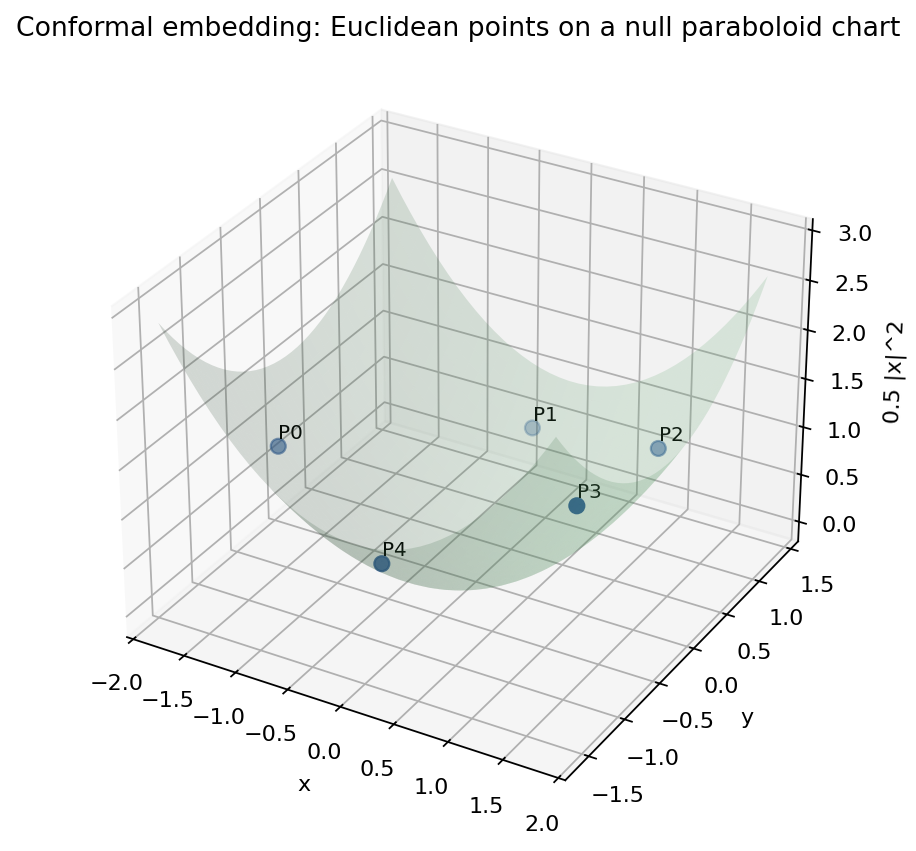

In [6]:
points = np.array([
    [-1.4, -0.7],
    [-0.2, 1.1],
    [1.2, 0.8],
    [1.6, -1.0],
    [0.1, -1.4],
])
embedded = np.array([conformal_point_2d(x, y) for x, y in points])
null_errors = np.array([abs(null_residual(point)) for point in embedded])

max_distance_error = 0.0
for i in range(len(points)):
    for j in range(len(points)):
        euclidean_squared = float(np.sum((points[i] - points[j]) ** 2))
        conformal_squared = conformal_distance_squared_2d(points[i], points[j])
        max_distance_error = max(max_distance_error, abs(euclidean_squared - conformal_squared))

z = embedded[:, 3]
fig = plt.figure(figsize=(7.2, 5.4))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points[:, 0], points[:, 1], z, color="#315c9b", s=45, depthshade=True)
for idx, (x, y, zz) in enumerate(zip(points[:, 0], points[:, 1], z, strict=True)):
    ax.text(x, y, zz + 0.08, f"P{idx}", fontsize=9)

gx = np.linspace(-1.8, 1.8, 40)
gy = np.linspace(-1.6, 1.4, 40)
GX, GY = np.meshgrid(gx, gy)
GZ = 0.5 * (GX**2 + GY**2)
ax.plot_surface(GX, GY, GZ, alpha=0.18, color="#5aa469", linewidth=0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("0.5 |x|^2")
ax.set_title("Conformal embedding: Euclidean points on a null paraboloid chart")
fig.tight_layout()
conformal_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "conformal-point-embedding.png", root=ARTIFACT_ROOT)
plt.close(fig)

conformal_report = {
    "max_null_residual": float(null_errors.max()),
    "max_distance_error": float(max_distance_error),
    "sample_inner_product_p0_p1": conformal_inner_2d(embedded[0], embedded[1]),
    "sample_distance_squared_p0_p1": conformal_distance_squared_2d(points[0], points[1]),
}
assert conformal_report["max_null_residual"] < 1e-10
assert conformal_report["max_distance_error"] < 1e-10
report_path = save_json(conformal_report, ARTIFACT_TOPIC, "checks", "conformal-distance-check.json", root=ARTIFACT_ROOT)
print(f"saved {conformal_path}")
print(f"saved {report_path}")
display_artifact(conformal_path, width=720)


## Operations Make The Model Alive

A model earns its keep through operations. A list of represented objects is only a dictionary. A working geometry needs products and transformations that do the right thing without constant translation back to ad hoc coordinate code.

For the vector-space model, the central operations are the outer product, contractions, the geometric product, and rotor sandwiches. These operations are excellent for attitudes. A plane blade can project a vector, a rotor can rotate a vector, and products can express angles and orientations. The model is alive as a geometry of directions.

For the homogeneous model, the central operations are join, meet, duality, and linear/projective transformations. The line through two points and the point where two lines meet are the same exterior-algebra habit seen from opposite sides. Transforming a point by a homogeneous matrix and transforming a line by the inverse transpose preserves incidence. That is the operational heart of projective geometry.

For the conformal model, the central operations include the inner product for distances and versor sandwiches for transformations. Once a point, sphere, circle, or plane is represented as a blade or dual blade, the same algebraic products can test incidence, compute intersections, and move objects. The model is heavier, but many algorithms become less fragmented because operations are no longer split between many special object classes.

The executable checks below use two modest invariants: homogeneous incidence survives a translation, and Euclidean pairwise distances survive a rotation before and after conformal embedding. These checks are small on purpose. If a model fails a tiny invariant, a large application built on it will fail in ways that are harder to diagnose.


In [7]:
T = translation_matrix(0.75, -0.35)
translated_meet = T @ meet
translated_line_a = transform_line(T, line_a)
translated_line_b = transform_line(T, line_b)
meet_after_transform = intersect_homogeneous_lines(translated_line_a, translated_line_b)

translated_meet_affine = normalize_homogeneous(translated_meet)
meet_after_affine = normalize_homogeneous(meet_after_transform)
projective_transform_error = float(np.linalg.norm(translated_meet_affine - meet_after_affine))
incidence_after_transform = max(
    abs(line_residual(translated_line_a, meet_after_transform)),
    abs(line_residual(translated_line_b, meet_after_transform)),
)

rotated_points = rotate2d(points, np.pi / 5)
distance_before = euclidean_distance_matrix(points)
distance_after = euclidean_distance_matrix(rotated_points)
rotation_distance_error = float(np.max(np.abs(distance_before - distance_after)))

operation_report = {
    "projective_transform_error": projective_transform_error,
    "incidence_after_transform": float(incidence_after_transform),
    "rotation_distance_error": rotation_distance_error,
    "translated_meet_affine": translated_meet_affine.tolist(),
    "meet_after_transform_affine": meet_after_affine.tolist(),
}
assert operation_report["projective_transform_error"] < 1e-10
assert operation_report["incidence_after_transform"] < 1e-10
assert operation_report["rotation_distance_error"] < 1e-10

operation_path = save_json(operation_report, ARTIFACT_TOPIC, "checks", "operation-invariants.json", root=ARTIFACT_ROOT)
print(f"saved {operation_path}")
operation_report


saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/checks/operation-invariants.json


{'projective_transform_error': 1.1188630228279524e-16,
 'incidence_after_transform': 5.551115123125783e-17,
 'rotation_distance_error': 4.440892098500626e-16,
 'translated_meet_affine': [0.9478494623655914, 0.10161290322580634, 1.0],
 'meet_after_transform_affine': [0.9478494623655913, 0.10161290322580632, 1.0]}

## How Chapters 10-17 Fit Together

Chapter 10 is the controlled baseline. It says: before adding coordinates, understand the vector-space model as an algebra of directions. This includes angular relationships, spherical triangles, point groups, and the places where a direction-only model can still support practical calibration tasks. It keeps the reader honest about what Part I already solved.

Chapters 11 and 12 then add one dimension and focus on homogeneous geometry. Chapter 11 develops the representation itself: finite points, points at infinity, direct and dual flats, incidence, and projective transformations. Chapter 12 shows why that model is not just formalism by applying it to Plucker coordinates, pinhole cameras, epipolar relationships, motion capture, OpenGL-style transformations, and crossing-line computations. In this region of the book, the question is usually projective: which flats contain which other flats, and how do observations constrain lines or planes?

Chapters 13-16 move to the conformal model. Chapter 13 introduces the representational space, the conformal metric, flat elements, motors, translations, rotations, and rigid-body interpolation. Chapter 14 expands the primitive set: point pairs, circles, spheres, tangents, the representative paraboloid, Voronoi reasoning, and metric uses of inner products. Chapter 15 turns those primitives into constructions involving incidence, coincidence, plunge, tangency, factorization, affine combinations, projection, and contour-circle style algorithms. Chapter 16 focuses on operators: spherical inversion, reflection in spheres, scaling and translation, logarithms of scaled motions, loxodromes, hyperbolic and spherical models, and imaging by the eye.

Chapter 17 steps back from the conformal model and asks the design question again. It treats algebras for geometries and operational definitions as a way to decide what should count as a model in the first place. This matters for computer science because implementations are not judged by elegance alone. They are judged by whether the chosen representation makes the intended operations stable, composable, and testable.


saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/checks/chapter-route.json
saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/figures/chapter-route-map.png


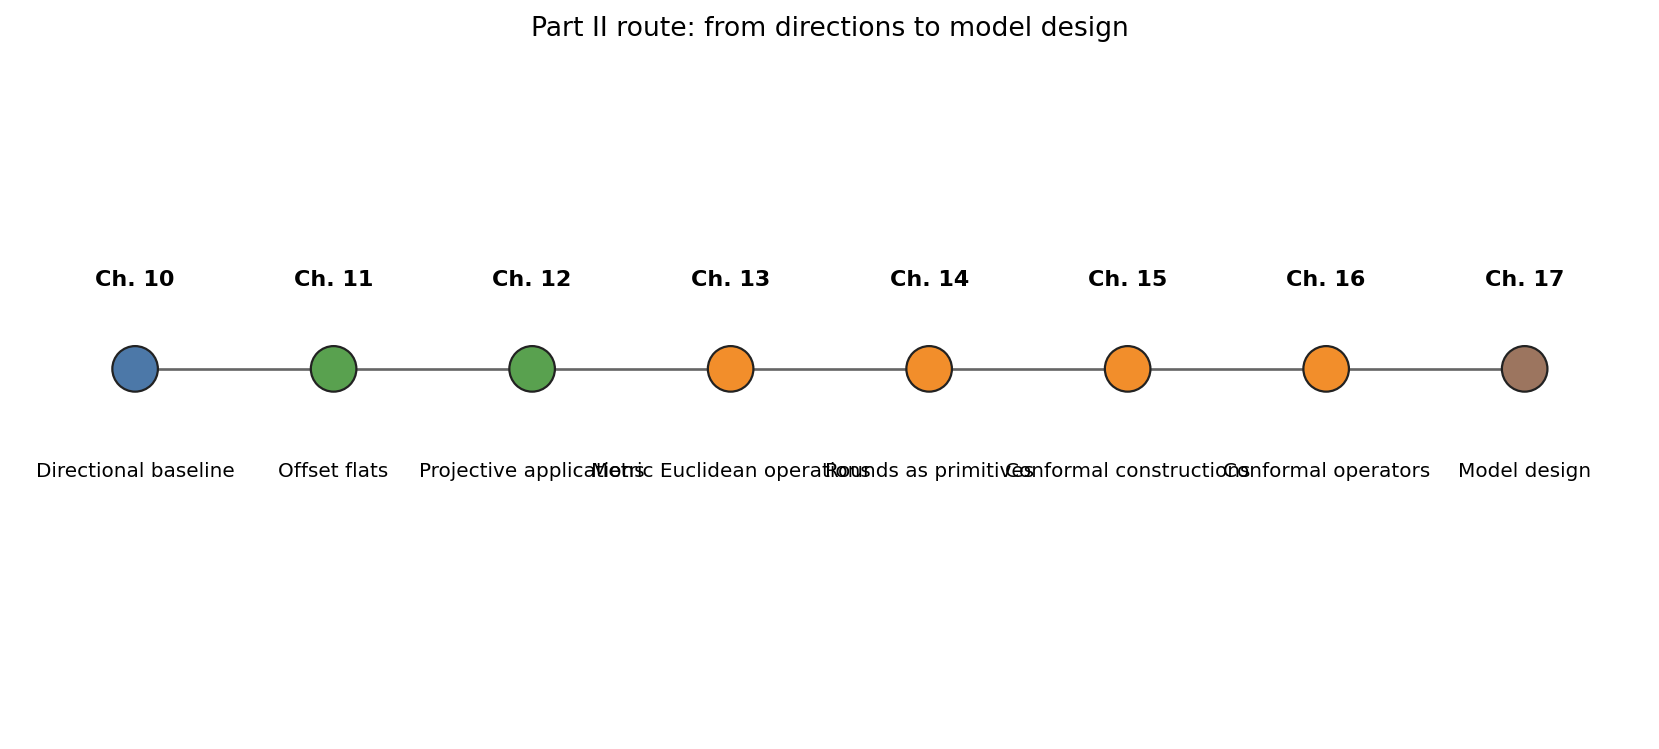

In [8]:
route = chapter_route()
route_path = save_json(route, ARTIFACT_TOPIC, "checks", "chapter-route.json", root=ARTIFACT_ROOT)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
y = np.zeros(len(route))
colors = ["#4c78a8", "#59a14f", "#59a14f", "#f28e2b", "#f28e2b", "#f28e2b", "#f28e2b", "#9c755f"]
ax.scatter(range(len(route)), y, s=420, c=colors, edgecolors="#222222", linewidths=1.0, zorder=3)
ax.plot(range(len(route)), y, color="#666666", linewidth=1.2, zorder=2)
for index, item in enumerate(route):
    ax.text(index, 0.12, f"Ch. {item['chapter']}", ha="center", va="bottom", fontsize=10, weight="bold")
    ax.text(index, -0.14, item["role"], ha="center", va="top", fontsize=9, wrap=True)
ax.set_ylim(-0.55, 0.45)
ax.set_xlim(-0.6, len(route) - 0.4)
ax.axis("off")
ax.set_title("Part II route: from directions to model design", pad=16)
fig.tight_layout()
route_fig_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "chapter-route-map.png", root=ARTIFACT_ROOT)
plt.close(fig)
print(f"saved {route_path}")
print(f"saved {route_fig_path}")
display_artifact(route_fig_path, width=900)


## Model Choice Checklist

The bridge chapter can be turned into a checklist for later work.

First, name the physical objects. Are they directions through one point, offset flats, rays, camera image lines, circles, spheres, tangents, rigid motions, inversions, or something else? A model that is perfect for one category may be clumsy for another.

Second, name the representational space. If physical `R^n` is enough, say why. If `R^(n+1)` is needed, identify the projective benefit. If a conformal `R^(n+1,1)` space is used, identify the metric or operator benefit that pays for the larger algebra. Do not add dimensions by habit. Add them because they remove a real modeling obstruction.

Third, name the metric. If the metric is Euclidean and nondegenerate, the geometric product has a direct quantitative interpretation. If the representation is projective, be explicit about which metric facts live outside the homogeneous algebra. If the metric is conformal and null, check the null embedding and the distance identity. A metric mistake is often more serious than a coordinate mistake because it corrupts the meaning of products.

Fourth, name the embedding and de-embedding. Write down how a physical point, direction, line, plane, circle, or motion becomes an algebraic element, and how the result is read back. Include scale conventions and failure cases such as points at infinity or null denominators.

Fifth, name the operations. A model is strong when the desired operations are native: joins for spanning, meets for incidence, contractions for projection, inner products for measurement, and versor sandwiches for structure-preserving transformations. If an operation requires leaving the model every time, the model may still be useful, but it is not carrying that part of the geometry.


In [9]:
artifact_candidates = [
    heading_path,
    profile_path,
    scorecard_path,
    line_path,
    report_path,
    conformal_path,
    operation_path,
    route_path,
    route_fig_path,
]

final_report = {
    "printed_pages_checked": [245, 246],
    "pdf_pages_checked": [272, 273],
    "visible_heading": heading_audit[0]["heading"],
    "model_profile_count": len(profiles),
    "route_entries": len(route),
    "saved_artifact_count": sum(Path(path).exists() for path in artifact_candidates),
    "saved_figures": [str(scorecard_path), str(line_path), str(conformal_path), str(route_fig_path)],
    "homogeneous_residual_max": max(
        abs(homogeneous_report["residual_line_a"]),
        abs(homogeneous_report["residual_line_b"]),
    ),
    "conformal_distance_max_error": conformal_report["max_distance_error"],
    "projective_transform_error": operation_report["projective_transform_error"],
    "rotation_distance_error": operation_report["rotation_distance_error"],
}

assert final_report["visible_heading"] == "9 MODELING GEOMETRIES"
assert final_report["model_profile_count"] == 4
assert final_report["route_entries"] == 8
assert len(final_report["saved_figures"]) >= 2
assert final_report["saved_artifact_count"] == len(artifact_candidates)
assert final_report["homogeneous_residual_max"] < 1e-10
assert final_report["conformal_distance_max_error"] < 1e-10
assert final_report["projective_transform_error"] < 1e-10
assert final_report["rotation_distance_error"] < 1e-10

final_path = save_json(final_report, ARTIFACT_TOPIC, "checks", "final-checks.json", root=ARTIFACT_ROOT)
print(f"saved {final_path}")
final_report
final_sanity = final_report
final_sanity


saved Geometric-Algebra-for-Computer-Science/artifacts/chapter-09/checks/final-checks.json


{'printed_pages_checked': [245, 246],
 'pdf_pages_checked': [272, 273],
 'visible_heading': '9 MODELING GEOMETRIES',
 'model_profile_count': 4,
 'route_entries': 8,
 'saved_artifact_count': 9,
 'saved_figures': ['Geometric-Algebra-for-Computer-Science//artifacts//chapter-09//figures//model-choice-scorecard.png',
  'Geometric-Algebra-for-Computer-Science//artifacts//chapter-09//figures//homogeneous-offset-lines.png',
  'Geometric-Algebra-for-Computer-Science//artifacts//chapter-09//figures//conformal-point-embedding.png',
  'Geometric-Algebra-for-Computer-Science//artifacts//chapter-09//figures//chapter-route-map.png'],
 'homogeneous_residual_max': 5.551115123125783e-17,
 'conformal_distance_max_error': 1.7763568394002505e-15,
 'projective_transform_error': 1.1188630228279524e-16,
 'rotation_distance_error': 4.440892098500626e-16}

## Closing Summary

Chapter 9 prepares the rest of Part II by changing the central question. The question is no longer only "Which geometric algebra product should I use?" It is also "Which model makes that product mean the intended geometry?" The vector-space model makes directions natural. The homogeneous model makes offset incidence and projective structure natural. The conformal model makes Euclidean metric operations, rounds, and many transformations natural. The operational viewpoint asks us to justify those choices by the invariants and algorithms we need.

The figures and checks in this notebook are meant to be reused as diagnostic habits. Plot the model tradeoffs. Check homogeneous incidence before normalizing. Check conformal null residuals before trusting distances. Check that transformations commute with the operations they are supposed to preserve. These small tests make model choice concrete, and they set up the more specialized chapters that follow.


## Takeaways

- `09 - Modeling Geometries` is treated as an executable geometric algebra lesson: definitions are paired with concrete representations, artifacts, and checks.
- The chapter's computations make the model choices visible, so algebraic operations can be inspected instead of accepted as black-box notation.
- The saved artifacts and sanity checks are the audit trail for this standalone notebook; they support the text without reproducing textbook prose or figures.